In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import BatchNormalization
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [3]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [4]:
print(y_train[0])

[6]


In [5]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [6]:
print(y_train[0])

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


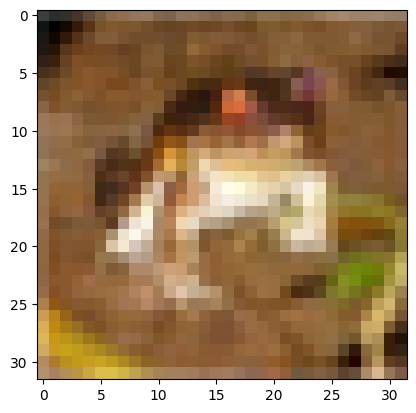

[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


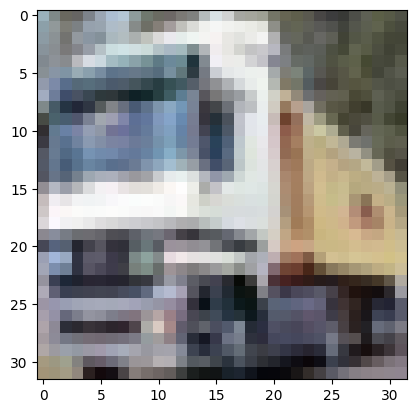

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


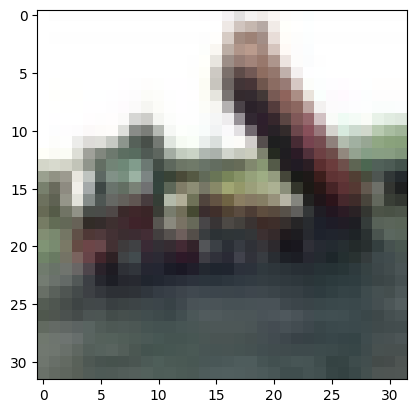

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


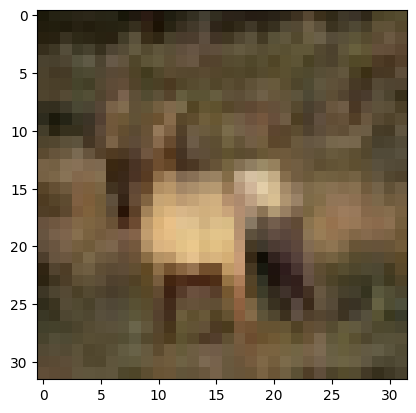

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


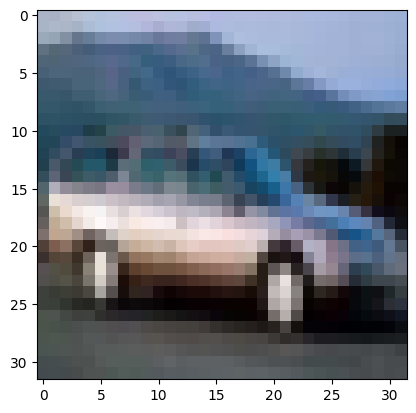

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


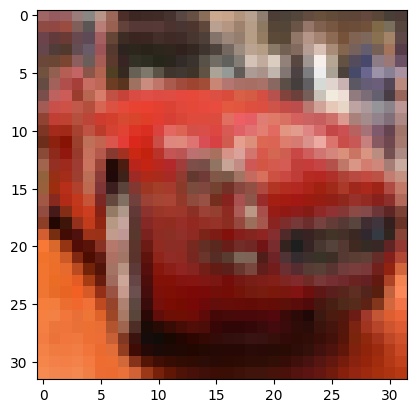

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


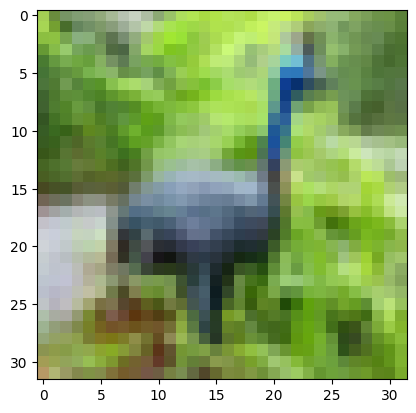

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


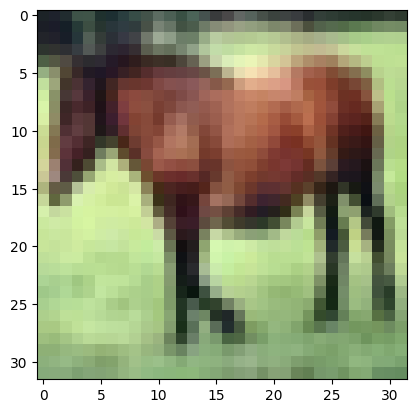

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


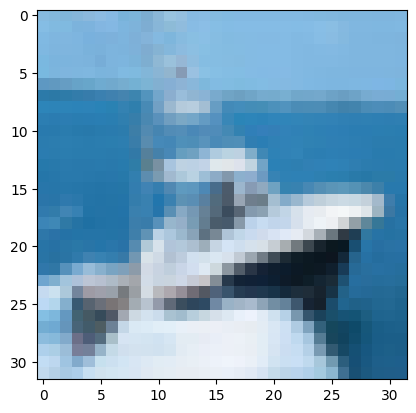

[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


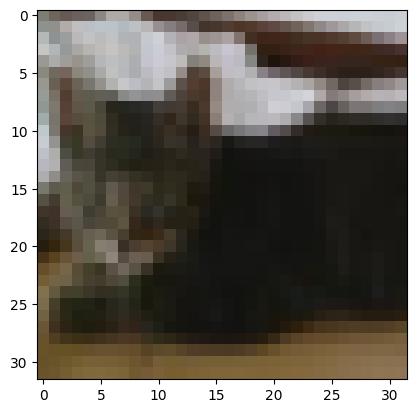

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


In [7]:
for i in range(10):
  plt.imshow(x_train[i])
  plt.show()
  print(y_train[i])

In [8]:
clasificador_cnn = keras.models.Sequential([
    keras.layers.Conv2D(32, 7, activation="relu", padding="same",
                       input_shape=[32,32,3]),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [9]:
clasificador_cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        4736      
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 16)        4624      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 16)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1024)              0         
                                                                 
 dense (Dense)               (None, 10)                1

In [10]:
clasificador_cnn.compile(loss="categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(), metrics=['accuracy'])

In [11]:
h = clasificador_cnn.fit(x_train, y_train, epochs=30, batch_size=1000, validation_split = 0.2)

Epoch 1/30
40/40 [==============================] - 10s 52ms/step - loss: 5.4166 - accuracy: 0.1003 - val_loss: 2.3026 - val_accuracy: 0.0978
Epoch 2/30
40/40 [==============================] - 1s 26ms/step - loss: 2.3027 - accuracy: 0.1005 - val_loss: 2.3024 - val_accuracy: 0.0980
Epoch 3/30
40/40 [==============================] - 1s 28ms/step - loss: 2.3026 - accuracy: 0.1005 - val_loss: 2.3024 - val_accuracy: 0.0980
Epoch 4/30
40/40 [==============================] - 1s 29ms/step - loss: 2.3026 - accuracy: 0.1005 - val_loss: 2.3024 - val_accuracy: 0.0980
Epoch 5/30
40/40 [==============================] - 1s 27ms/step - loss: 2.3026 - accuracy: 0.1005 - val_loss: 2.3025 - val_accuracy: 0.0980
Epoch 6/30
40/40 [==============================] - 1s 28ms/step - loss: 2.3026 - accuracy: 0.1005 - val_loss: 2.3025 - val_accuracy: 0.0980
Epoch 7/30
40/40 [==============================] - 1s 24ms/step - loss: 2.3026 - accuracy: 0.1005 - val_loss: 2.3025 - val_accuracy: 0.0980
Epoch 8/30
4

In [12]:
test_loss, test_accuracy = clasificador_cnn.evaluate(x_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 2.3034 - accuracy: 0.1000


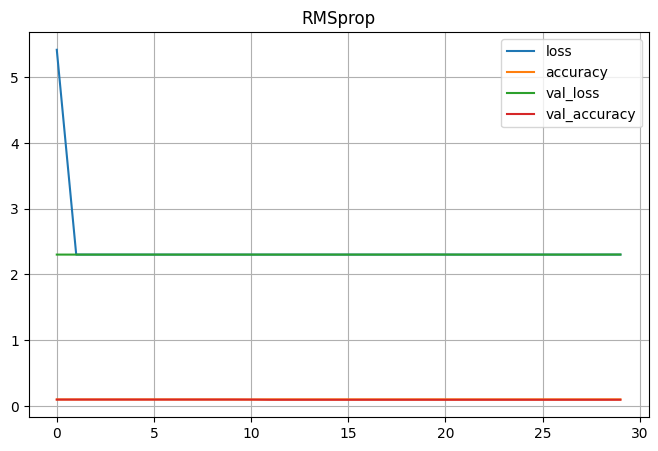

In [13]:
pd.DataFrame(h.history).plot(figsize=(8, 5))
plt.title('RMSprop')
plt.grid(True)
plt.show()

In [14]:
predictions = clasificador_cnn.predict(x_test)

313/313 [==============================] - 1s 2ms/step


In [15]:
def one_hot_vector(vec):
  max_idx = -1
  max_element = -1
  for i in range(len(vec)):
    if vec[i] > max_element:
      max_idx = i
      max_element = vec[i]
  ohv = np.zeros( len(vec) )
  ohv[max_idx] = 1
  return ohv

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


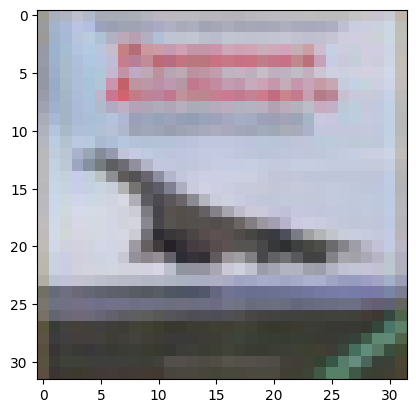

In [16]:
img_input_id = 3
ohv = one_hot_vector( predictions[img_input_id] )
print( ohv )
print( y_test[img_input_id] )
plt.imshow( x_test[img_input_id] );